In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login, hf_hub_download
import os

login(token='<>')

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned",
    filename="train_clean.zip",
    repo_type="dataset",
    local_dir="/kaggle/working"
)

hf_hub_download(
    repo_id="Harsh2005/DeepFashion2-Pruned",
    filename="validation_clean.zip",
    repo_type="dataset",
    local_dir="/kaggle/working"
)

!unzip -q /kaggle/working/train_clean.zip -d /kaggle/working/train
!unzip -q /kaggle/working/validation_clean.zip -d /kaggle/working/val

os.remove("/kaggle/working/train_clean.zip")
os.remove("/kaggle/working/validation_clean.zip")

print("Data ready.")

train_clean.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

validation_clean.zip:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Data ready.


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dhrramjos (kronpoz) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loaded model from /kaggle/working/working/unet_epoch_10.pth
Found 23741 validation samples
Eval loader has 2968 batches
Running inference...


Evaluating: 100%|██████████| 2968/2968 [03:36<00:00, 13.73it/s]
/tmp/ipykernel_23/2176378383.py:152: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(precisions, recalls)



--- PIXEL-LEVEL METRICS ---
Category                       IoU     Dice
---------------------------------------------
short sleeve top            0.7197   0.8370
trousers                    0.7192   0.8367
shorts                      0.5771   0.7319
long sleeve top             0.5955   0.7465
skirt                       0.6927   0.8185

Macro mIoU : 0.6608
Macro Dice : 0.7941

--- INSTANCE-LEVEL mAP ---
Category                    AP@0.5  AP@0.5:0.95
--------------------------------------------------
short sleeve top            0.8670       0.6985
trousers                    0.8603       0.6007
shorts                      0.8009       0.5763
long sleeve top             0.7916       0.6018
skirt                       0.8337       0.6749

mAP@0.50      : 0.8307
mAP@0.50:0.95 : 0.6304

--- ROC AUC + F1 ---
Category                       AUC       F1
---------------------------------------------
short sleeve top            0.9257   0.8820
trousers                    0.9612   0.9021
shorts

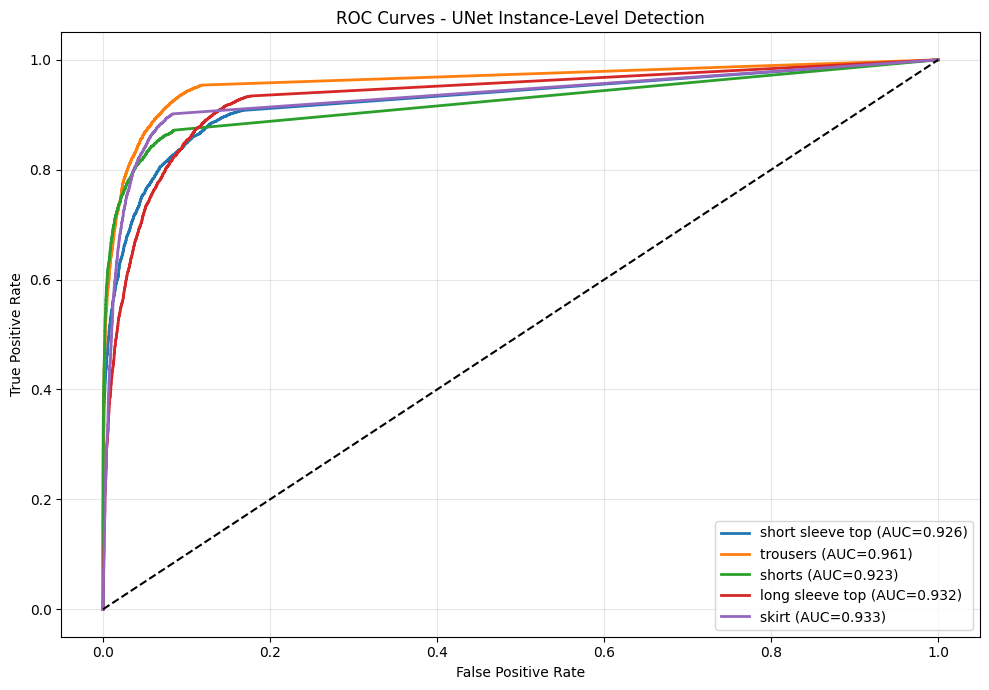

ROC plot saved.


In [ ]:
import wandb
import torch
import torch.nn as nn
import numpy as np
import cv2
from glob import glob
import json
import os
from tqdm import tqdm
import segmentation_models_pytorch as smp
from sklearn.metrics import roc_curve, auc, f1_score
import matplotlib.pyplot as plt
from collections import defaultdict
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

CATEGORIES = ["short sleeve top", "trousers", "shorts", "long sleeve top", "skirt"]
CAT_TO_IDX = {cat: i+1 for i, cat in enumerate(CATEGORIES)}
IDX_TO_CAT = {i+1: cat for i, cat in enumerate(CATEGORIES)}
NUM_CLASSES = 6
IOU_THRESHOLDS = np.arange(0.5, 1.0, 0.05)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DOWNLOAD MODEL FROM WANDB ---
wandb.login(key='<>')
api = wandb.Api()
run = api.run("kronpoz/deepfashion-unet/i5nw9hk3")

target_file = None
for f in run.files():
    if "unet_epoch_10.pth" in f.name:
        target_file = f.name
        break

print(f"Downloading {target_file}...")
run.file(target_file).download(root="/kaggle/working", replace=True)

DOWNLOADED_PATH = os.path.join("/kaggle/working", target_file)
model = smp.Unet(encoder_name="resnet34", encoder_weights=None, in_channels=3, classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(DOWNLOADED_PATH, map_location=device))
model.eval()
print(f"Loaded model from {DOWNLOADED_PATH}")

# --- DATASET ---
class EvalSegDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.json_paths = glob(os.path.join(root_dir, '**/*.json'), recursive=True)
        print(f"Found {len(self.json_paths)} validation samples")

    def __len__(self):
        return len(self.json_paths)

    def __getitem__(self, idx):
        json_path = self.json_paths[idx]
        with open(json_path, 'r') as f:
            data = json.load(f)

        img_path = json_path.replace('.json', '.jpg').replace('annos', 'image')
        if not os.path.exists(img_path):
            img_path = json_path.replace('.json', '.jpg')

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask  = np.zeros(image.shape[:2], dtype=np.uint8)

        gt_instances = []
        for key, value in data.items():
            if key.startswith('item') and isinstance(value, dict):
                c_name = value.get('category_name')
                if c_name in CAT_TO_IDX and 'segmentation' in value:
                    inst_mask = np.zeros(image.shape[:2], dtype=np.uint8)
                    for poly in value['segmentation']:
                        seg = np.array(poly, dtype=np.int32).reshape(-1, 2)
                        cv2.fillPoly(mask, [seg], CAT_TO_IDX[c_name])
                        cv2.fillPoly(inst_mask, [seg], 1)
                    gt_instances.append({
                        'category_idx': CAT_TO_IDX[c_name],
                        'mask': inst_mask
                    })

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']

        return image, mask.long(), gt_instances

def collate_fn(batch):
    images  = torch.stack([b[0] for b in batch])
    masks   = torch.stack([b[1] for b in batch])
    gt_inst = [b[2] for b in batch]
    return images, masks, gt_inst

val_ts = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

eval_dataset = EvalSegDataset('/kaggle/working/val/validation', val_ts)
eval_loader  = DataLoader(eval_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"Eval loader has {len(eval_loader)} batches")

# --- HELPERS ---
def extract_instances(semantic_mask, pred_probs_np):
    instances = []
    for cls in range(1, NUM_CLASSES):
        binary = (semantic_mask == cls).astype(np.uint8)
        num_labels, labels_map, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        for label_id in range(1, num_labels):
            area = stats[label_id, cv2.CC_STAT_AREA]
            if area < 100:
                continue
            x1 = stats[label_id, cv2.CC_STAT_LEFT]
            y1 = stats[label_id, cv2.CC_STAT_TOP]
            w  = stats[label_id, cv2.CC_STAT_WIDTH]
            h  = stats[label_id, cv2.CC_STAT_HEIGHT]
            component_mask = (labels_map == label_id).astype(np.uint8)
            score = float(pred_probs_np[cls][component_mask.astype(bool)].mean())
            instances.append({
                'category_idx': cls,
                'bbox': [x1, y1, x1+w, y1+h],
                'mask': component_mask,
                'score': score
            })
    return instances

def mask_iou(m1, m2):
    intersection = (m1 & m2).sum()
    union = (m1 | m2).sum()
    return intersection / (union + 1e-7)

def compute_ap(pred_list, n_gt, iou_threshold=0.5):
    if n_gt == 0 or len(pred_list) == 0:
        return 0.0
    pred_list_sorted = sorted(pred_list, key=lambda x: x[0], reverse=True)
    n_tp, n_fp = 0, 0
    tp_list, fp_list = [], []
    for score, best_iou in pred_list_sorted:
        if best_iou >= iou_threshold:
            n_tp += 1
        else:
            n_fp += 1
        tp_list.append(n_tp)
        fp_list.append(n_fp)
    precisions = [tp / (tp + fp + 1e-7) for tp, fp in zip(tp_list, fp_list)]
    recalls    = [tp / (n_gt + 1e-7) for tp in tp_list]
    recalls    = [0.0] + recalls + [1.0]
    precisions = [1.0] + precisions + [0.0]
    return np.trapz(precisions, recalls)

# --- INFERENCE ---
print("Running inference...")

total_tp_px = torch.zeros(NUM_CLASSES - 1)
total_fp_px = torch.zeros(NUM_CLASSES - 1)
total_fn_px = torch.zeros(NUM_CLASSES - 1)

all_pred_instances = defaultdict(list)
all_gt_counts      = defaultdict(int)
all_gt_labels      = defaultdict(list)
all_pred_scores    = defaultdict(list)

with torch.no_grad():
    for imgs, masks, gt_inst_batch in tqdm(eval_loader, desc="Evaluating"):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        for c in range(1, NUM_CLASSES):
            idx    = c - 1
            pred_c = (preds == c)
            mask_c = (masks == c)
            total_tp_px[idx] += (pred_c & mask_c).sum().cpu()
            total_fp_px[idx] += (pred_c & ~mask_c).sum().cpu()
            total_fn_px[idx] += (~pred_c & mask_c).sum().cpu()

        for b in range(imgs.shape[0]):
            pred_mask_np  = preds[b].cpu().numpy().astype(np.uint8)
            pred_probs_np = probs[b].cpu().numpy()

            pred_instances = extract_instances(pred_mask_np, pred_probs_np)
            gt_instances   = gt_inst_batch[b]

            gt_instances_resized = []
            for gt in gt_instances:
                m = cv2.resize(gt['mask'], (224, 224), interpolation=cv2.INTER_NEAREST)
                if not m.any():
                    continue
                gt_instances_resized.append({
                    'category_idx': gt['category_idx'],
                    'mask': m.astype(bool),
                    'matched': False
                })

            for gt in gt_instances_resized:
                all_gt_counts[gt['category_idx']] += 1

            for c in range(1, NUM_CLASSES):
                gt_present = int(any(g['category_idx'] == c for g in gt_instances_resized))
                pred_score = float(pred_probs_np[c].max()) if (pred_mask_np == c).any() else 0.0
                all_gt_labels[c].append(gt_present)
                all_pred_scores[c].append(pred_score)

            gt_matched_flags = [False] * len(gt_instances_resized)
            for pred in pred_instances:
                cat          = pred['category_idx']
                score        = pred['score']
                best_iou_val = 0.0
                best_gt_idx  = -1
                for gi, gt in enumerate(gt_instances_resized):
                    if gt['category_idx'] != cat or gt_matched_flags[gi]:
                        continue
                    iou_val = mask_iou(pred['mask'].astype(bool), gt['mask'])
                    if iou_val > best_iou_val:
                        best_iou_val = iou_val
                        best_gt_idx  = gi
                all_pred_instances[cat].append((score, best_iou_val))
                if best_gt_idx >= 0 and best_iou_val >= 0.5:
                    gt_matched_flags[best_gt_idx] = True

# --- PIXEL METRICS ---
ious  = total_tp_px / (total_tp_px + total_fp_px + total_fn_px + 1e-7)
dices = (2 * total_tp_px) / ((2 * total_tp_px) + total_fp_px + total_fn_px + 1e-7)

print("\n--- PIXEL-LEVEL METRICS ---")
print(f"{'Category':<25} {'IoU':>8} {'Dice':>8}")
print("-" * 45)
for i, cat in enumerate(CATEGORIES):
    print(f"{cat:<25} {ious[i].item():>8.4f} {dices[i].item():>8.4f}")
print(f"\nMacro mIoU : {ious.mean().item():.4f}")
print(f"Macro Dice : {dices.mean().item():.4f}")

# --- mAP ---
print("\n--- INSTANCE-LEVEL mAP ---")
print(f"{'Category':<25} {'AP@0.5':>8} {'AP@0.5:0.95':>12}")
print("-" * 50)

all_ap50, all_ap50_95 = [], []
for c in range(1, NUM_CLASSES):
    cat     = IDX_TO_CAT[c]
    n_gt    = all_gt_counts[c]
    preds_c = all_pred_instances[c]
    ap50    = compute_ap(preds_c, n_gt, iou_threshold=0.5)
    ap50_95 = np.mean([compute_ap(preds_c, n_gt, iou_threshold=t) for t in IOU_THRESHOLDS])
    all_ap50.append(ap50)
    all_ap50_95.append(ap50_95)
    print(f"{cat:<25} {ap50:>8.4f} {ap50_95:>12.4f}")

print(f"\nmAP@0.50      : {np.mean(all_ap50):.4f}")
print(f"mAP@0.50:0.95 : {np.mean(all_ap50_95):.4f}")

# --- ROC + AUC + F1 ---
print("\n--- ROC AUC + F1 ---")
print(f"{'Category':<25} {'AUC':>8} {'F1':>8}")
print("-" * 45)

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(1, NUM_CLASSES):
    cat    = IDX_TO_CAT[c]
    gt_arr = np.array(all_gt_labels[c])
    sc_arr = np.array(all_pred_scores[c])

    # skip if only one class present in gt
    if len(np.unique(gt_arr)) < 2:
        print(f"{cat:<25} {'N/A':>8} {'N/A':>8}")
        continue

    fpr, tpr, _ = roc_curve(gt_arr, sc_arr)
    roc_auc     = auc(fpr, tpr)
    f1          = f1_score(gt_arr, (sc_arr > 0.5).astype(int), zero_division=0)
    print(f"{cat:<25} {roc_auc:>8.4f} {f1:>8.4f}")
    ax.plot(fpr, tpr, lw=2, label=f"{cat} (AUC={roc_auc:.3f})")

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - UNet Instance-Level Detection")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curves_unet.png', dpi=200)
plt.show()
print("ROC plot saved.")